In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "prophet==1.3.0" "statsmodels==0.14.6"

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from prophet import Prophet
import warnings; warnings.filterwarnings("ignore")
import cmdstanpy; cmdstanpy.utils.get_logger().disabled = True   # 적합 때마다 찍히는 진행 로그를 끈다
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다
SEED = 42        # Prophet 의 구간은 시뮬레이션이라 시드를 고정해야 본문 숫자가 재현된다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 31.6 MB/s eta 0:00:00
사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


표 1 · 예측 원점 5개의 168시간 RMSE (대)
  예측 원점        계절 나이브 168   Prophet 기본 구성
  10월 19일 23시            306.52              366.49
  10월 26일 23시            418.18              410.68
  11월  2일 23시            457.07              474.90
  11월  9일 23시            430.72              342.82
  11월 16일 23시            205.25              310.42
  평균                      363.55              381.06
표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)
  잠재적 변화점          25
  연간 계절성 포함 적합  0
  연간 계절성 제외 적합  7


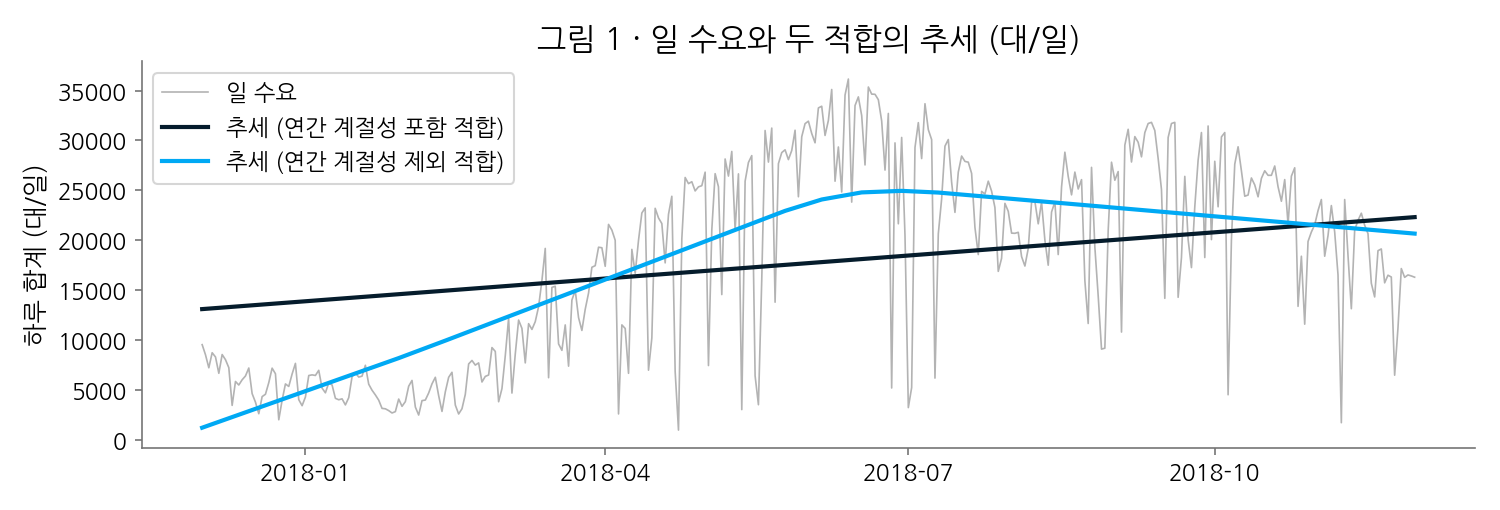

In [2]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1 · 표 2 · 그림 1 을 만듭니다. Prophet 을 7번 적합해 30초 안팎 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

# 표 1: 금요일 23시 예측 원점 5개마다 9월 1일부터 원점까지로 재적합해 168시간을 한 번에 예측한다
origins = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")
origin_rmse = []                          # (원점, 계절 나이브 168, Prophet 기본 구성)
for o in origins:
    fit_part = df.loc["2018-09-01 00:00":o, "demand"]
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")
    m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                holidays=holidays_one, uncertainty_samples=0)          # 구간 없이 예측값만 낸다
    m.fit(pd.DataFrame({"ds": fit_part.index, "y": fit_part.values}))
    y_week = df.loc[week, "demand"]
    origin_rmse.append((o, rmse(y_week, df["demand"].shift(168).loc[week]),    # 1주일 전 같은 시각 값
                        rmse(y_week, m.predict(pd.DataFrame({"ds": week}))["yhat"])))
sn5_mean = float(np.mean([r[1] for r in origin_rmse]))
p5_mean = float(np.mean([r[2] for r in origin_rmse]))
print("표 1 · 예측 원점 5개의 168시간 RMSE (대)")
print("  예측 원점        계절 나이브 168   Prophet 기본 구성")
for o, sn, pr in origin_rmse:
    print(f"  {o.month:>2}월 {o.day:>2}일 23시   {sn:15.2f}   {pr:17.2f}")
print(f"  평균             {sn5_mean:15.2f}   {p5_mean:17.2f}")

# 표 2 · 그림 1: 일 수요 365일에 연간 계절성을 포함한 적합과 제외한 적합, 잠재적 변화점의 성장률 변화량을 센다
_sum = df["demand"].resample("D").sum()                     # 보정 수요의 하루 합계
daily = pd.DataFrame({"ds": _sum.index, "y": _sum.values})
cp_count, daily_trend = {}, {}
for yearly in (True, False):
    m = Prophet(yearly_seasonality=yearly, weekly_seasonality=True, daily_seasonality=False,
                uncertainty_samples=0)                      # 일 수요에는 하루 안의 주기가 없다
    m.fit(daily)
    delta = m.params["delta"].mean(axis=0)                  # 잠재적 변화점마다 성장률 변화량
    cp_count[yearly] = int((np.abs(delta) > 0.01).sum())
    daily_trend[yearly] = m.predict(daily)["trend"].values
print("표 2 · 일 수요 365일 추세의 변화량이 큰 변화점 수 (개)")
print(f"  잠재적 변화점          {len(m.changepoints)}")
print(f"  연간 계절성 포함 적합  {cp_count[True]}")
print(f"  연간 계절성 제외 적합  {cp_count[False]}")

fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.plot(daily["ds"], daily["y"], color=COL["연회색"], lw=0.8, label="일 수요")
ax.plot(daily["ds"], daily_trend[True], color=COL["남색"], lw=2.0, label="추세 (연간 계절성 포함 적합)")
ax.plot(daily["ds"], daily_trend[False], color=COL["하늘색"], lw=2.0, label="추세 (연간 계절성 제외 적합)")
ax.set_title("그림 1 · 일 수요와 두 적합의 추세 (대/일)")
ax.set_ylabel("하루 합계 (대/일)")
datefmt(ax, "%Y-%m", 7)
ax.legend(loc="upper left")
plt.show()

In [3]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표

print(f"학습 {len(train):,}시간  {train.index[0]:%m-%d %H시} ~ {train.index[-1]:%m-%d %H시}")
print(f"검증 {len(valid):,}시간  {valid.index[0]:%m-%d %H시} ~ {valid.index[-1]:%m-%d %H시}")
print(f"휴일 데이터프레임 {len(holidays_one)}행, 열 {list(holidays_one.columns)}")
print(f"시드 SEED = {SEED}: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임)"
      " · SEED (시드) · rmse(a, b)")

학습 1,848시간  09-01 00시 ~ 11-16 23시
검증 168시간  11-17 00시 ~ 11-23 23시
휴일 데이터프레임 18행, 열 ['holiday', 'ds']
시드 SEED = 42: 예측구간은 표본 경로로 만들어 적합 직전과 예측 직전에 한 번씩 고정합니다
쓸 수 있는 이름 : train · valid (시간 표, 열 demand) · holidays_one (휴일 데이터프레임) · SEED (시드) · rmse(a, b)


명목 포함률 = 80 %
실제 포함률 = 89.88 %  (151 / 168시간)
아래로 벗어남 = 12시간 · 위로 벗어남 = 5시간


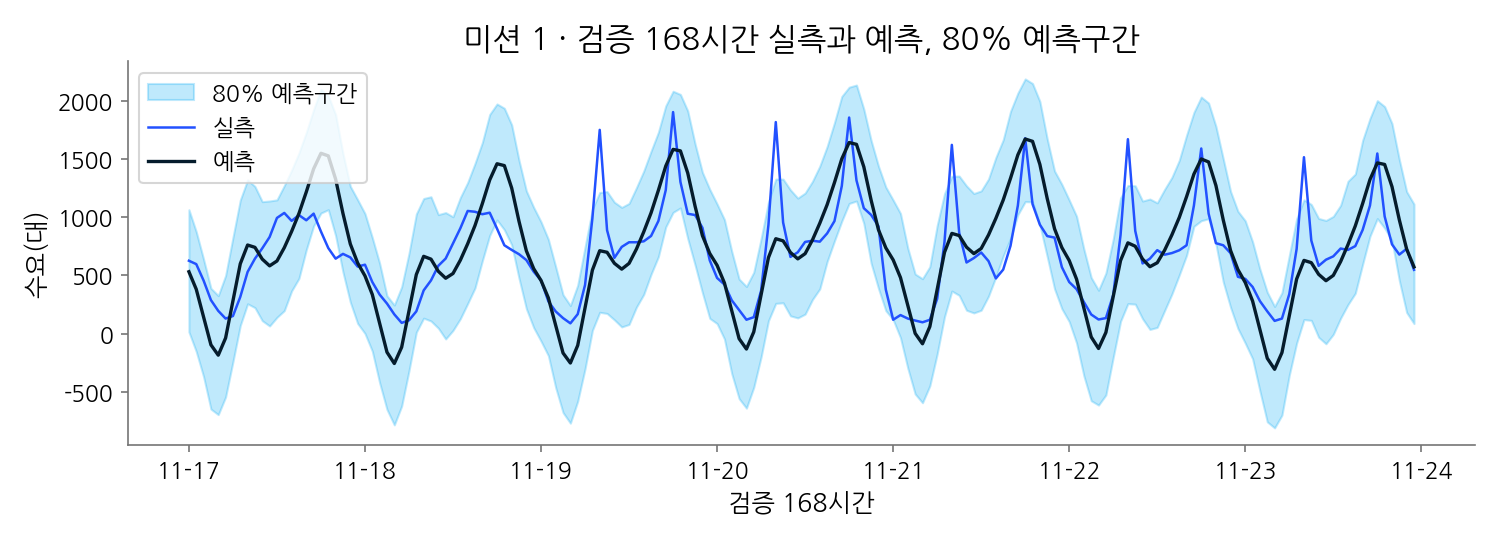

In [5]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
위 준비 셀이 만든 train, valid, holidays_one, SEED 와 설치 셀의 rmse(a, b), COL, FIG_W, datefmt 는
이미 있으니 다시 만들거나 덮어쓰지 마. 데이터를 다시 읽지도 마.

1) Prophet 기본 구성으로 모형 m 을 만들어:
   yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True, holidays=holidays_one.
   interval_width 와 uncertainty_samples 는 지정하지 말고 Prophet 기본값을 그대로 둬
   (uncertainty_samples=0 을 쓰면 구간이 사라지니 절대 넣지 마).
2) train 의 인덱스를 ds, demand 열을 y 로 한 데이터프레임으로 적합해.
   적합 직전에 np.random.seed(SEED) 를 불러.
3) valid 의 인덱스 168시각을 ds 로 넣어 예측해. 예측 직전에 다시 np.random.seed(SEED) 를 불러.
4) 명목 포함률은 숫자를 손으로 적지 말고 m.interval_width 에서 읽어 % 정수로 만들어.
   실제 포함률은 valid["demand"] 가 yhat_lower 이상이고 yhat_upper 이하인 시각의 비율을
   % 소수 둘째 자리로 계산하고, 그 시각이 168시간 중 몇 시간인지도 세어.
   구간 아래(실측 < yhat_lower)와 위(실측 > yhat_upper)로 벗어난 시각 수도 세어.
5) 출력은 정확히 이 모양으로 한 행씩:
   명목 포함률 = 80 %
   실제 포함률 = xx.xx %  (n / 168시간)
   아래로 벗어남 = a시간 · 위로 벗어남 = b시간
6) 그래프 한 장: 폭 FIG_W, 실측선은 COL["파랑"], 예측선(yhat)은 COL["남색"],
   예측구간은 fill_between 으로 COL["하늘색"] 을 옅게(alpha 0.25) 칠해.
   가로축 라벨 "검증 168시간", 세로축 라벨 "수요(대)", 범례 표시,
   제목의 구간 비율도 명목 포함률 변수로 넣어. 날짜 눈금은 datefmt 로 정리해.
"""
# --- 여기부터 AI 코드 ---

# ── AI 코드 ──────────────────────────────────────────────
# 1) Prophet 기본 구성 (interval_width · uncertainty_samples 는 기본값 그대로)
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
            holidays=holidays_one)

# 2) 적합 — 적합 직전에 시드 고정
np.random.seed(SEED)
m.fit(pd.DataFrame({"ds": train.index, "y": train["demand"].values}))

# 3) 예측 — 예측 직전에 다시 시드 고정
np.random.seed(SEED)
fc = m.predict(pd.DataFrame({"ds": valid.index}))

# 4) 포함률 계산
y    = valid["demand"].values
yhat = fc["yhat"].values
lo   = fc["yhat_lower"].values
hi   = fc["yhat_upper"].values

inside  = (y >= lo) & (y <= hi)
nominal = int(round(m.interval_width * 100))     # 모형에서 읽은 명목 포함률
actual  = inside.mean() * 100                    # 실제 포함률
n_in    = int(inside.sum())
n_below = int((y < lo).sum())
n_above = int((y > hi).sum())

# 5) 출력
print(f"명목 포함률 = {nominal} %")
print(f"실제 포함률 = {actual:.2f} %  ({n_in} / {len(y)}시간)")
print(f"아래로 벗어남 = {n_below}시간 · 위로 벗어남 = {n_above}시간")

# 6) 그래프
fig, ax = plt.subplots(figsize=(FIG_W, 3.6))
ax.fill_between(valid.index, lo, hi, color=COL["하늘색"], alpha=0.25,
                label=f"{nominal}% 예측구간")
ax.plot(valid.index, y,    color=COL["파랑"], lw=1.2, label="실측")
ax.plot(valid.index, yhat, color=COL["남색"], lw=1.6, label="예측")
ax.set_title(f"미션 1 · 검증 168시간 실측과 예측, {nominal}% 예측구간")
ax.set_xlabel("검증 168시간")
ax.set_ylabel("수요(대)")
datefmt(ax, "%m-%d", 8)
ax.legend(loc="upper left")
plt.show()

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로

train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]      # 검증 168시간
hol_days = sorted(set(df.index[df["holiday"].eq("Holiday")].normalize()))
holidays_one = pd.DataFrame({"holiday": "공휴일", "ds": hol_days})   # 공휴일 18일을 이름 하나로 묶은 표
REGS = ["rain", "temp"]                                    # 더할 외생 변수 두 열

#  비교할 두 RMSE 를 이 셀에서 다시 만든다. 날씨 없는 Prophet 기본 구성과 1주일 전 같은 시각 값
m_base = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
                 holidays=holidays_one, uncertainty_samples=0)
m_base.fit(pd.DataFrame({"ds": train.index, "y": train["demand"].values}))
BASE_RMSE = rmse(valid["demand"], m_base.predict(pd.DataFrame({"ds": valid.index}))["yhat"])
SNAIVE_RMSE = rmse(valid["demand"], df["demand"].shift(168).loc[valid.index])

q05 = train["temp"].quantile(0.05)                        # 학습 기온을 낮은 쪽부터 정렬한 5% 지점
print(f"학습 {len(train):,}시간 · 검증 {len(valid)}시간 · 휴일 데이터프레임 {len(holidays_one)}행")
print(f"기온 평균: 학습 {train['temp'].mean():.2f}도, 검증 {valid['temp'].mean():.2f}도")
print(f"검증 168시간 가운데 학습 기온의 5% 지점({q05:.1f}도)보다 추운 시각: "
      f"{int((valid['temp'] < q05).sum())}시간")
print(f"비 온 시각: 학습 {int((train['rain'] > 0).sum())}시간, 검증 {int((valid['rain'] > 0).sum())}시간")
print(f"비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 {BASE_RMSE:.2f}대, 계절 나이브 168 {SNAIVE_RMSE:.2f}대")
print("쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열)"
      " · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)")

학습 1,848시간 · 검증 168시간 · 휴일 데이터프레임 18행
기온 평균: 학습 15.83도, 검증 4.91도
검증 168시간 가운데 학습 기온의 5% 지점(6.2도)보다 추운 시각: 101시간
비 온 시각: 학습 95시간, 검증 2시간
비교할 두 RMSE: 날씨 없는 Prophet 기본 구성 310.42대, 계절 나이브 168 205.25대
쓸 수 있는 이름 : train · valid (시간 표, 열 demand·temp·rain) · holidays_one · REGS (더할 두 열) · BASE_RMSE · SNAIVE_RMSE (비교할 두 RMSE, 대) · SEED (시드) · rmse(a, b)


날씨를 더한 RMSE = 342.21 대
기온 계수 = 40.42 대/도
판단: 이번 검증 구간에서는 날씨 열을 더하지 않는다 (날씨 없음 310.42 → 날씨 있음 342.21대) · 운영에서는 rain·temp 의 미래 값을 기상 예보로 채운다


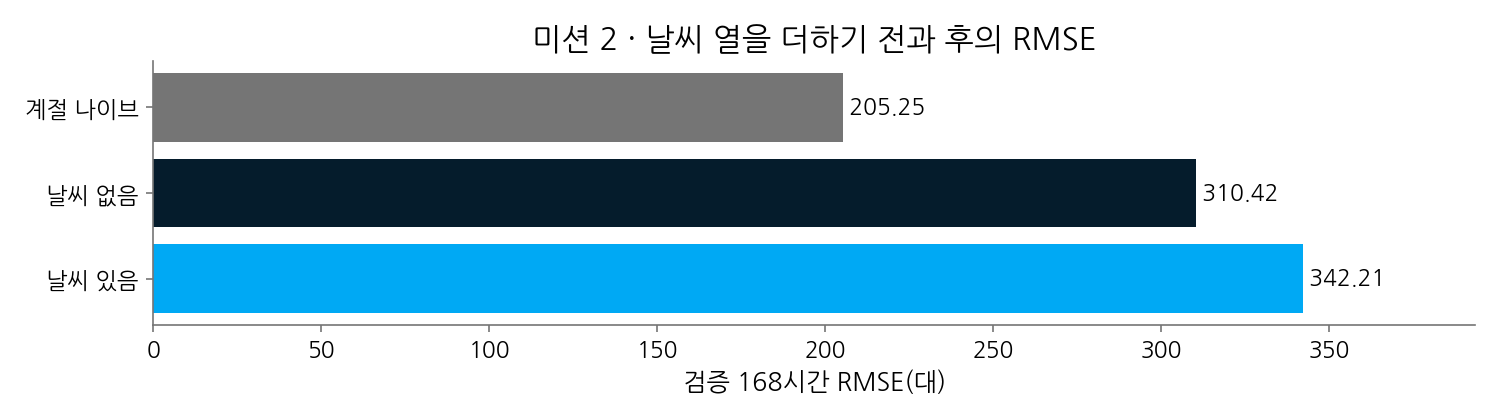

In [6]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
위 준비 셀이 만든 train, valid, holidays_one, REGS, BASE_RMSE, SNAIVE_RMSE, SEED 와
설치 셀의 rmse(a, b), COL, FIG_W 는 이미 있으니 다시 만들거나 덮어쓰지 마. 데이터를 다시 읽지도 마.

1) 미션 1 과 같은 성분 구성으로 모형 m 을 만들어:
   yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True, holidays=holidays_one.
   다른 설정은 바꾸지 말고, REGS 의 각 열을 m.add_regressor 로 더하기만 해.
2) 학습 표는 ds=train 인덱스, y=train["demand"], 그리고 REGS 두 열(rain, temp)을 train 에서 가져와 둬.
   적합 직전에 np.random.seed(SEED) 를 불러.
3) 예측 표는 ds=valid 인덱스와 REGS 두 열을 valid 의 실측 날씨로 채워 둬.
   예측 직전에 다시 np.random.seed(SEED) 를 불러.
4) 날씨를 더한 RMSE 는 rmse(valid["demand"], yhat) 로 계산해.
5) 기온 계수는 m.params 를 손으로 복원하지 말고
   from prophet.utilities import regressor_coefficients 로 불러서,
   regressor 가 "temp" 인 행의 coef 를 읽어.
6) 출력은 정확히 이 모양으로 한 행씩:
   날씨를 더한 RMSE = xx.xx 대
   기온 계수 = xx.xx 대/도
   판단: (날씨 RMSE 가 BASE_RMSE 보다 작은지에 따라 더할지 말지) · 운영에서는 두 열의 미래 값을 기상 예보로 채운다
7) 그래프 한 장: 폭 FIG_W 의 가로 막대 3개.
   막대 이름과 값은 "계절 나이브"=SNAIVE_RMSE, "날씨 없음"=BASE_RMSE, "날씨 있음"=날씨를 더한 RMSE,
   색은 차례로 COL["회색"], COL["남색"], COL["하늘색"].
   가로축 라벨 "검증 168시간 RMSE(대)", 막대 끝에 값을 소수 둘째 자리로 적어.
"""
# --- 여기부터 AI 코드 ---

# ── AI 코드 ──────────────────────────────────────────────
from prophet.utilities import regressor_coefficients

# 1) 미션 1 과 같은 성분 구성 + 날씨 두 열
m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=True,
            holidays=holidays_one)
for col in REGS:
    m.add_regressor(col)

# 2) 학습 표 — 날씨 두 열 포함, 적합 직전 시드 고정
fit_df = pd.DataFrame({"ds": train.index, "y": train["demand"].values})
for col in REGS:
    fit_df[col] = train[col].values
np.random.seed(SEED)
m.fit(fit_df)

# 3) 예측 표 — 검증 구간의 실측 날씨 대입, 예측 직전 시드 고정
pred_df = pd.DataFrame({"ds": valid.index})
for col in REGS:
    pred_df[col] = valid[col].values
np.random.seed(SEED)
fc = m.predict(pred_df)

# 4) 날씨를 더한 RMSE
WEATHER_RMSE = rmse(valid["demand"], fc["yhat"])

# 5) 기온 계수 — 원래 단위(대/도)로 복원된 값
coefs = regressor_coefficients(m)
temp_coef = float(coefs.loc[coefs["regressor"] == "temp", "coef"].iloc[0])

# 6) 출력
print(f"날씨를 더한 RMSE = {WEATHER_RMSE:.2f} 대")
print(f"기온 계수 = {temp_coef:.2f} 대/도")
add = "더한다" if WEATHER_RMSE < BASE_RMSE else "더하지 않는다"
print(f"판단: 이번 검증 구간에서는 날씨 열을 {add} "
      f"(날씨 없음 {BASE_RMSE:.2f} → 날씨 있음 {WEATHER_RMSE:.2f}대) · "
      "운영에서는 rain·temp 의 미래 값을 기상 예보로 채운다")

# 7) 가로 막대 그래프
names  = ["계절 나이브", "날씨 없음", "날씨 있음"]
values = [SNAIVE_RMSE, BASE_RMSE, WEATHER_RMSE]
colors = [COL["회색"], COL["남색"], COL["하늘색"]]

fig, ax = plt.subplots(figsize=(FIG_W, 2.8))
bars = ax.barh(names, values, color=colors)
for b, v in zip(bars, values):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:.2f}", va="center")
ax.invert_yaxis()                                  # 위에서부터 계절 나이브 → 날씨 있음
ax.set_xlabel("검증 168시간 RMSE(대)")
ax.set_title("미션 2 · 날씨 열을 더하기 전과 후의 RMSE")
ax.set_xlim(0, max(values) * 1.15)                 # 값 라벨이 잘리지 않게
plt.show()